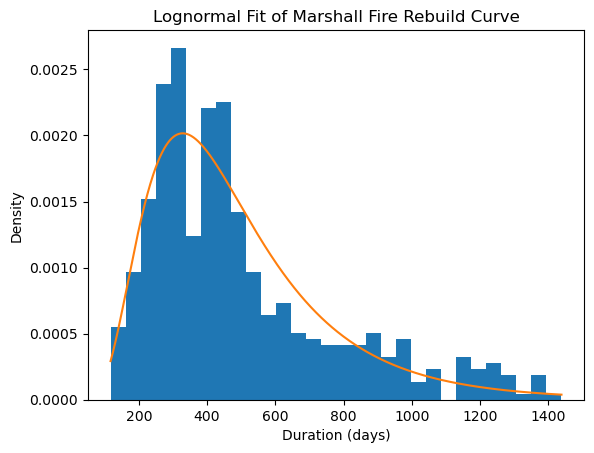

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

df = pd.read_csv("disaster_to_application_louisville.csv")
data = df["duration_days"]

shape, loc, scale = lognorm.fit(data, floc=0)

x = np.linspace(min(data), max(data), 1000)

plt.hist(data, bins=30, density=True)
plt.plot(x, lognorm.pdf(x, shape, loc, scale))

plt.xlabel("Duration (days)")
plt.ylabel("Density")
plt.title("Lognormal Fit of Marshall Fire Rebuild Curve")
plt.show()

In [3]:
print(shape)
print(scale)

0.5250260688883092
432.50326827660706


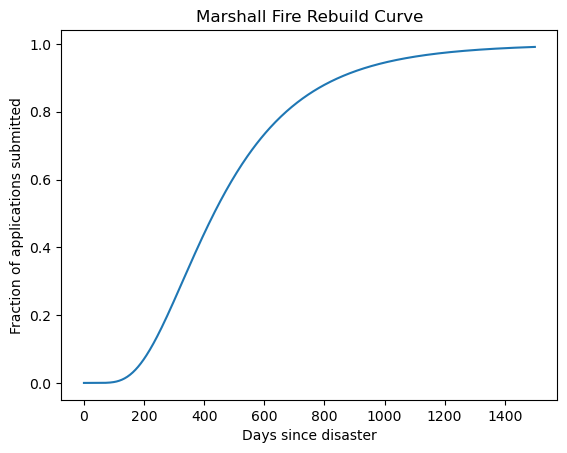

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

x = np.linspace(0, 1500, 500)

cdf = lognorm.cdf(x, shape, loc, scale)

plt.plot(x, cdf)
plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Marshall Fire Rebuild Curve")
plt.show()

In [3]:
N = 6410   # example total damaged homes

predicted_apps = N * cdf

pdf = lognorm.pdf(x, shape, loc, scale)
daily_submissions = N * pdf

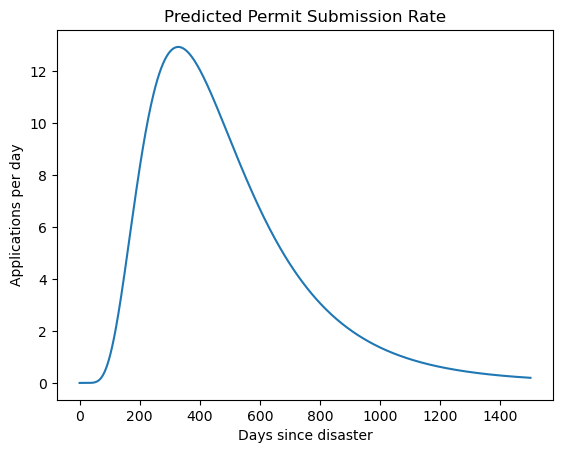

In [4]:
plt.plot(x, daily_submissions)
plt.xlabel("Days since disaster")
plt.ylabel("Applications per day")
plt.title("Predicted Permit Submission Rate")
plt.show()

In [5]:
print(shape)
print(loc)
print(scale)

0.5250260688883092
0
432.50326827660706


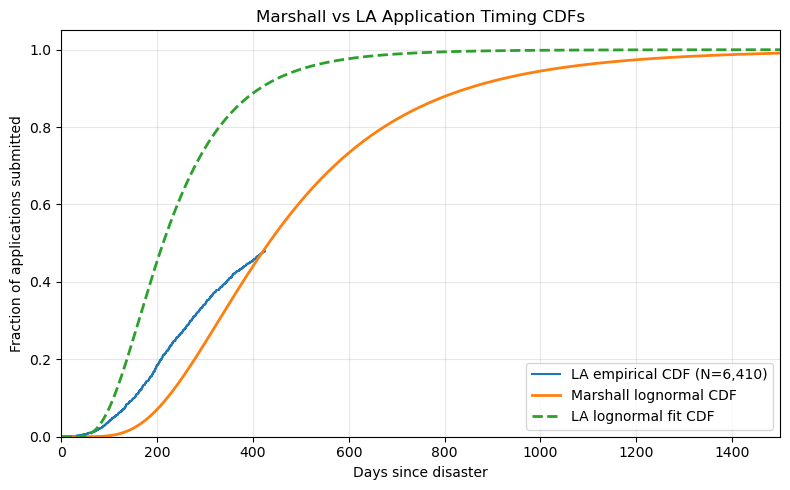

In [6]:
# LA data + lognormal fit + comparison with Marshall CDF

# Load LA data
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values

# Fit a lognormal to LA data (fix location at 0 like Marshall)
shape_la, loc_la, scale_la = lognorm.fit(data_la, floc=0)

# Use the same x-grid as for Marshall
x_grid = x

# Marshall Fire CDF (already computed as `cdf`)
cdf_marshall = cdf

# LA fitted lognormal CDF
cdf_la_fit = lognorm.cdf(x_grid, shape_la, loc_la, scale_la)

# Empirical CDF for LA, scaled by total expected applications N = 6410
N_la = 6410
data_la_sorted = np.sort(data_la)
empirical_cdf_la = np.arange(1, len(data_la_sorted) + 1) / N_la

plt.figure(figsize=(8, 5))

# Empirical CDF for LA
plt.step(data_la_sorted, empirical_cdf_la, where="post", label="LA empirical CDF (N=6,410)")

# Marshall Fire lognormal CDF
plt.plot(x_grid, cdf_marshall, label="Marshall lognormal CDF", linewidth=2)

# LA lognormal fit CDF
plt.plot(x_grid, cdf_la_fit, label="LA lognormal fit CDF", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Marshall vs LA Application Timing CDFs")
plt.xlim(0, 1500)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

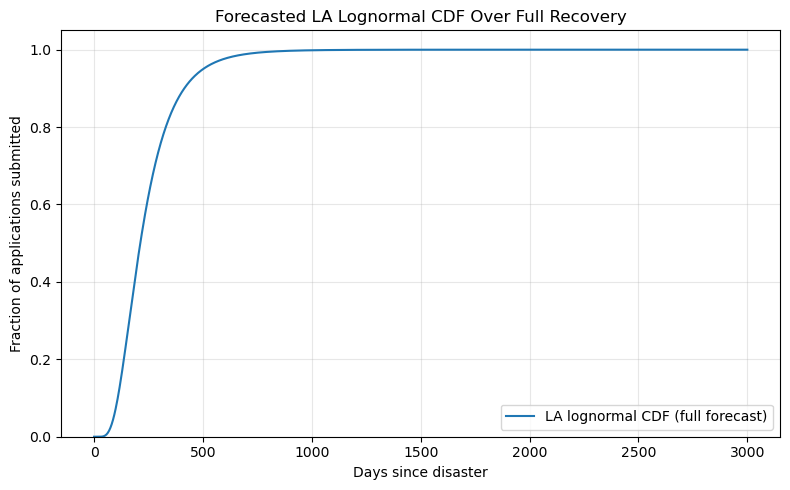

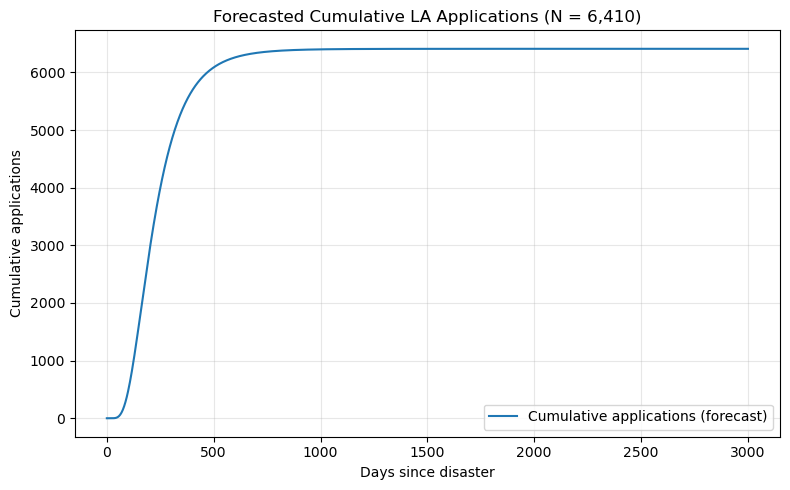

In [9]:
# Forecast LA lognormal CDF and applications over full recovery

# Use the LA lognormal fit you already estimated:
# shape_la, loc_la, scale_la

N_la = 6410  # total expected applications

# Choose a horizon long enough to see the curve saturate
x_forecast = np.linspace(0, 3000, 1000)  # days since disaster

# Full (unscaled) LA lognormal CDF and PDF
cdf_la_full = lognorm.cdf(x_forecast, shape_la, loc_la, scale_la)
pdf_la_full = lognorm.pdf(x_forecast, shape_la, loc_la, scale_la)

# Forecast cumulative and daily applications
cum_apps_la = N_la * cdf_la_full          # cumulative forecast
daily_apps_la = N_la * pdf_la_full        # daily forecast

plt.figure(figsize=(8, 5))
plt.plot(x_forecast, cdf_la_full, label="LA lognormal CDF (full forecast)")
plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Forecasted LA Lognormal CDF Over Full Recovery")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_forecast, cum_apps_la, label="Cumulative applications (forecast)")
plt.xlabel("Days since disaster")
plt.ylabel("Cumulative applications")
plt.title("Forecasted Cumulative LA Applications (N = 6,410)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

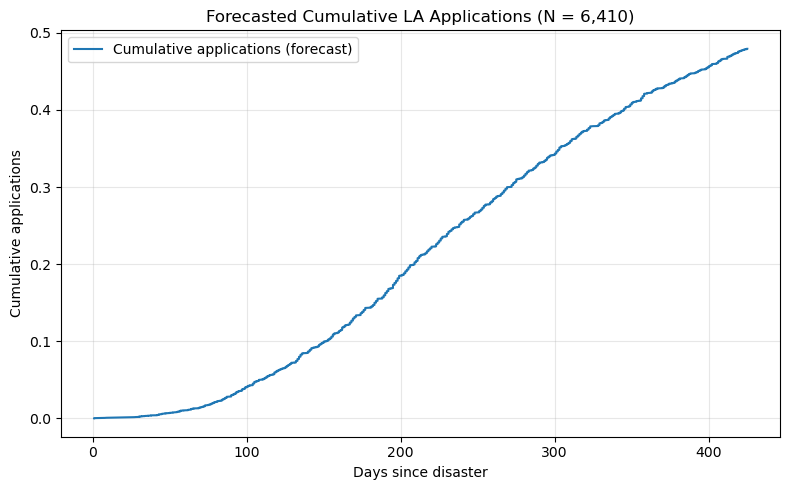

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(data_la_sorted, empirical_cdf_la, label="Cumulative applications (forecast)")
plt.xlabel("Days since disaster")
plt.ylabel("Cumulative applications")
plt.title("Forecasted Cumulative LA Applications (N = 6,410)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Estimated parameters
sigma = 0.8414086909222512
scale = 426.87404876775025


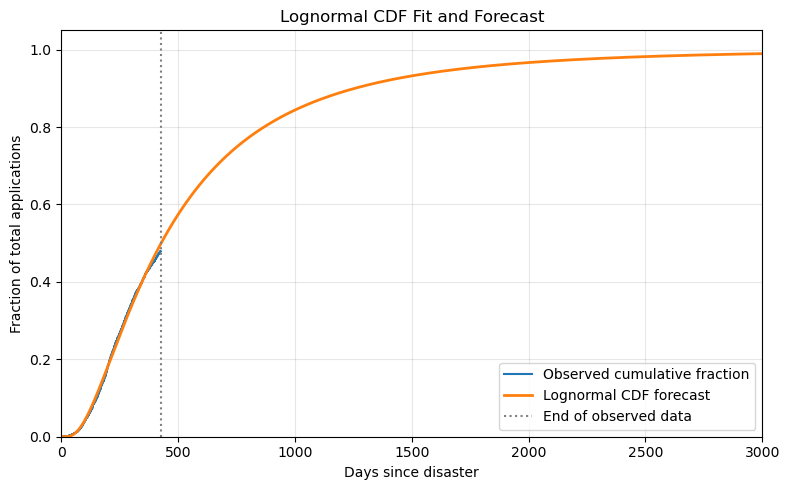

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import curve_fit

# --------------------------------
# Data
# --------------------------------
x = data_la_sorted
y = empirical_cdf_la

# --------------------------------
# Lognormal CDF function
# --------------------------------
def lognormal_cdf(x, sigma, scale):
    return lognorm.cdf(x, sigma, loc=0, scale=scale)

# --------------------------------
# Fit parameters to empirical CDF
# --------------------------------
p0 = [1.0, np.median(x)]  # initial guess

params, cov = curve_fit(
    lognormal_cdf,
    x,
    y,
    p0=p0,
    bounds=(0, np.inf)
)

sigma_hat, scale_hat = params

print("Estimated parameters")
print("sigma =", sigma_hat)
print("scale =", scale_hat)

# --------------------------------
# Forecast horizon
# --------------------------------
x_forecast = np.linspace(0, 3000, 1000)

cdf_forecast = lognorm.cdf(x_forecast, sigma_hat, loc=0, scale=scale_hat)

# --------------------------------
# Plot
# --------------------------------
plt.figure(figsize=(8,5))

plt.step(x, y, where="post", label="Observed cumulative fraction")

plt.plot(x_forecast, cdf_forecast,
         linewidth=2,
         label="Lognormal CDF forecast")

plt.axvline(x.max(), linestyle=":", color="gray",
            label="End of observed data")

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of total applications")
plt.title("Lognormal CDF Fit and Forecast")

plt.xlim(0,3000)
plt.ylim(0,1.05)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

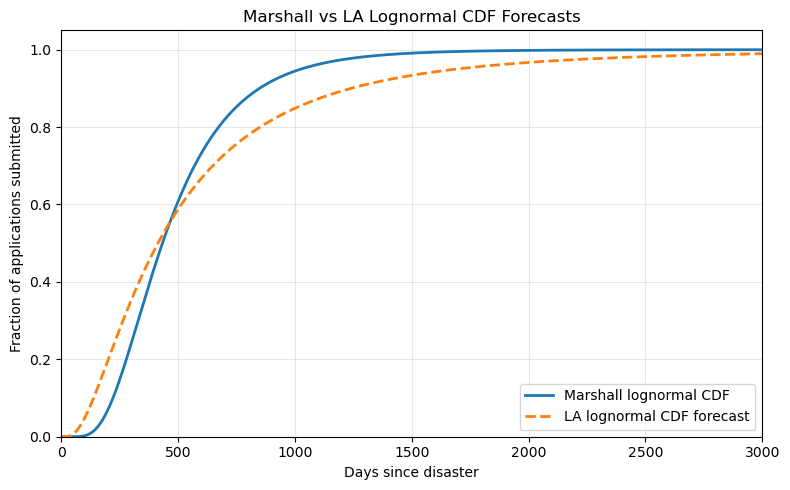

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Horizon for comparison
x_forecast = np.linspace(0, 3000, 1000)

# Marshall lognormal CDF (Marshall fit: shape, loc, scale)
cdf_marshall = lognorm.cdf(x_forecast, shape, loc, scale)

# LA lognormal CDF forecast (LA fit: shape_la, loc_la, scale_la)
cdf_la_forecast = lognorm.cdf(x_forecast, shape_la, loc_la, scale_la)

plt.figure(figsize=(8, 5))

plt.plot(x_forecast, cdf_marshall,
         label="Marshall lognormal CDF", linewidth=2)

plt.plot(x_forecast, cdf_la_forecast,
         label="LA lognormal CDF forecast", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Marshall vs LA Lognormal CDF Forecasts")
plt.xlim(0, 3000)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

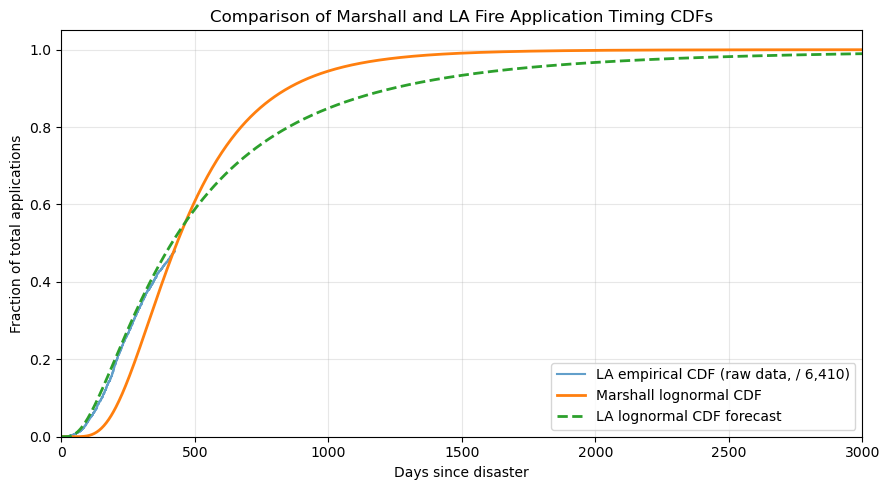

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

N_total = 6410  # total expected applications

# --- Load LA raw data ---
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values
data_la_sorted = np.sort(data_la)
n_la = len(data_la_sorted)

# Empirical CDF from raw LA data, scaled by total expected applications
empirical_cdf_la = np.arange(1, n_la + 1) / N_total

# --- Horizon for model CDFs ---
x_forecast = np.linspace(0, 3000, 1000)

# Marshall lognormal CDF (Marshall fit: shape, loc, scale)
cdf_marshall = lognorm.cdf(x_forecast, shape, loc, scale)

# LA lognormal CDF forecast (LA fit: shape_la, loc_la, scale_la)
cdf_la_forecast = lognorm.cdf(x_forecast, shape_la, loc_la, scale_la)

plt.figure(figsize=(9, 5))

# Raw LA empirical CDF (only where we have data)
plt.step(data_la_sorted, empirical_cdf_la, where="post",
         label="LA empirical CDF (raw data, / 6,410)", alpha=0.7)

# Marshall lognormal CDF
plt.plot(x_forecast, cdf_marshall,
         label="Marshall lognormal CDF", linewidth=2)

# LA lognormal CDF forecast
plt.plot(x_forecast, cdf_la_forecast,
         label="LA lognormal CDF forecast", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of total applications")
plt.title("Comparison of Marshall and LA Fire Application Timing CDFs")
plt.xlim(0, 3000)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import lognorm, kstest, anderson

# Load Marshall Fire / Louisville data
df_marshal = pd.read_csv("disaster_to_application_louisville.csv")
data_marshal = df_marshal["duration_days"].values

# Fit lognormal (Marshall) – if you already have shape, loc, scale you can skip refitting
shape_m, loc_m, scale_m = lognorm.fit(data_marshal, floc=0)

# 1) Kolmogorov–Smirnov test for fitted lognormal
#    H0: data come from Lognormal(shape_m, loc_m, scale_m)
ks_stat, ks_p = kstest(
    data_marshal,
    'lognorm',
    args=(shape_m, loc_m, scale_m)
)

# 2) Anderson–Darling test for lognormal
ad_result = anderson(np.log(data_marshal), dist='norm')  # log of data should be normal
ad_stat = ad_result.statistic
ad_crit = ad_result.critical_values
ad_sig = ad_result.significance_level

# 3) Log-likelihood, AIC, BIC for the fitted lognormal
n = len(data_marshal)
logpdf_vals = lognorm.logpdf(data_marshal, shape_m, loc=loc_m, scale=scale_m)
loglik = np.sum(logpdf_vals)

k = 3  # number of parameters: shape, loc, scale (loc fixed at 0 => k=2 if you used floc=0)
aic = 2 * k - 2 * loglik
bic = k * np.log(n) - 2 * loglik

print("Marshall lognormal fit parameters:")
print(f"  shape = {shape_m:.6f}, loc = {loc_m:.6f}, scale = {scale_m:.6f}\n")

print("Kolmogorov–Smirnov test:")
print(f"  KS statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}\n")

print("Anderson–Darling test on log-data vs Normal (lognormal check):")
print(f"  AD statistic = {ad_stat:.4f}")
for sl, cv in zip(ad_sig, ad_crit):
    print(f"  Critical value {cv:.4f} at significance level {sl:.1f}%")
print()

print("Information criteria for lognormal fit:")
print(f"  Log-likelihood = {loglik:.2f}")
print(f"  AIC = {aic:.2f}")
print(f"  BIC = {bic:.2f}")

Marshall lognormal fit parameters:
  shape = 0.525026, loc = 0.000000, scale = 432.503268

Kolmogorov–Smirnov test:
  KS statistic = 0.0523, p-value = 0.1292

Anderson–Darling test on log-data vs Normal (lognormal check):
  AD statistic = 2.0429
  Critical value 0.5710 at significance level 15.0%
  Critical value 0.6510 at significance level 10.0%
  Critical value 0.7810 at significance level 5.0%
  Critical value 0.9110 at significance level 2.5%
  Critical value 1.0830 at significance level 1.0%

Information criteria for lognormal fit:
  Log-likelihood = -3381.05
  AIC = 6768.09
  BIC = 6780.70


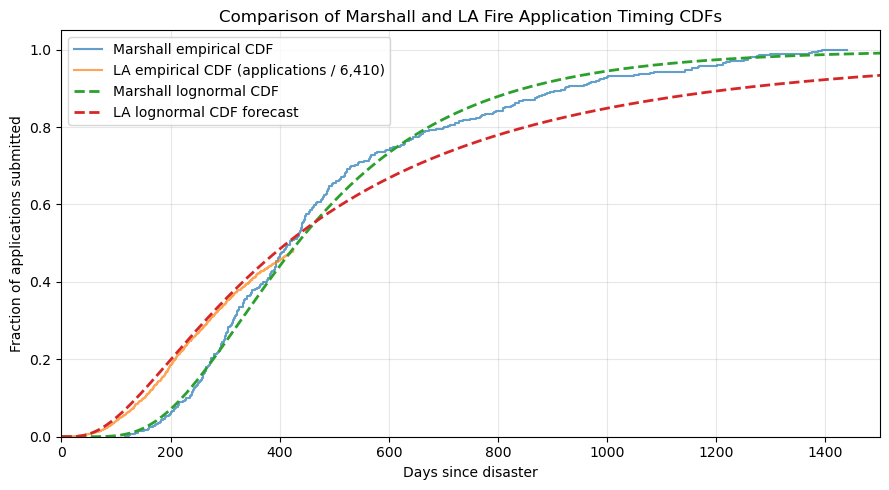

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

N_la = 6410  # total expected LA applications

# --- Load LA data ---
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values
data_la_sorted = np.sort(data_la)
n_la = len(data_la_sorted)

# LA empirical CDF as fraction of total expected LA applications
empirical_cdf_la = np.arange(1, n_la + 1) / N_la

# --- Load Marshall data (empirical) ---
df_marshall = pd.read_csv("disaster_to_application_louisville.csv")
data_marshall = df_marshall["duration_days"].values
data_marshall_sorted = np.sort(data_marshall)
n_marshall = len(data_marshall_sorted)

# Marshall empirical CDF (assume dataset includes all Marshall applications)
empirical_cdf_marshall = np.arange(1, n_marshall + 1) / n_marshall

# --- Horizon for model CDFs ---
x_forecast = np.linspace(0, 3000, 1000)

# Marshall lognormal CDF (Marshall fit: shape, loc, scale)
cdf_marshall = lognorm.cdf(x_forecast, shape, loc, scale)

# LA lognormal CDF forecast (LA fit: shape_la, loc_la, scale_la)
cdf_la_forecast = lognorm.cdf(x_forecast, shape_la, loc_la, scale_la)

plt.figure(figsize=(9, 5))

# Marshall empirical CDF (raw Marshall data)
plt.step(
    data_marshall_sorted, empirical_cdf_marshall, where="post",
    label="Marshall empirical CDF", alpha=0.7
)

# LA empirical CDF (raw LA data, scaled by 6,410)
plt.step(
    data_la_sorted, empirical_cdf_la, where="post",
    label="LA empirical CDF (applications / 6,410)", alpha=0.7
)

# Marshall lognormal CDF
plt.plot(
    x_forecast, cdf_marshall,
    label="Marshall lognormal CDF", linestyle="--", linewidth=2
)

# LA lognormal CDF forecast
plt.plot(
    x_forecast, cdf_la_forecast,
    label="LA lognormal CDF forecast", linestyle="--", linewidth=2
)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Comparison of Marshall and LA Fire Application Timing CDFs")
plt.xlim(0, 1500)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
print(shape)
print(loc)
print(scale)

0.5250260688883092
0
432.50326827660706


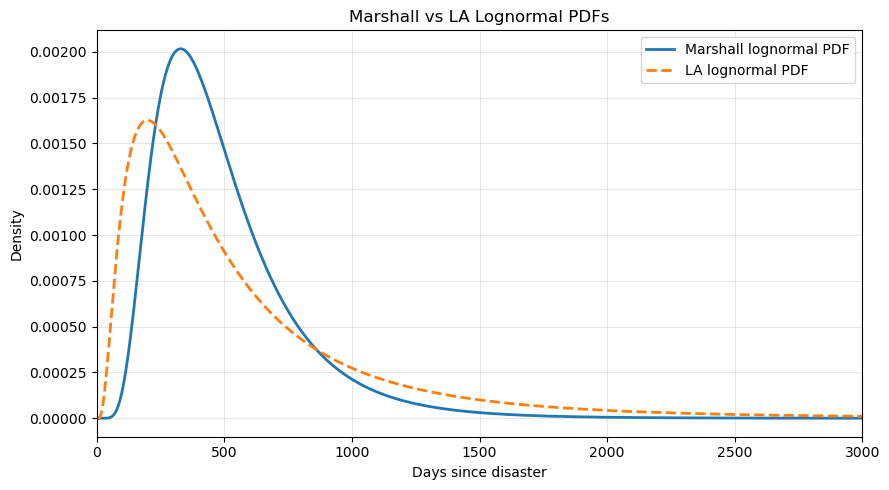

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Assumes you already have:
# Marshall: shape, loc, scale
# LA:       shape_la, loc_la, scale_la

# Common x-range for PDFs
x_pdf = np.linspace(0, 3000, 1000)

# Marshall lognormal PDF
pdf_marshall = lognorm.pdf(x_pdf, shape, loc=loc, scale=scale)

# LA lognormal PDF
pdf_la = lognorm.pdf(x_pdf, shape_la, loc=loc_la, scale=scale_la)

plt.figure(figsize=(9, 5))

plt.plot(x_pdf, pdf_marshall, label="Marshall lognormal PDF", linewidth=2)
plt.plot(x_pdf, pdf_la, label="LA lognormal PDF", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Density")
plt.title("Marshall vs LA Lognormal PDFs")
plt.xlim(0, 3000)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

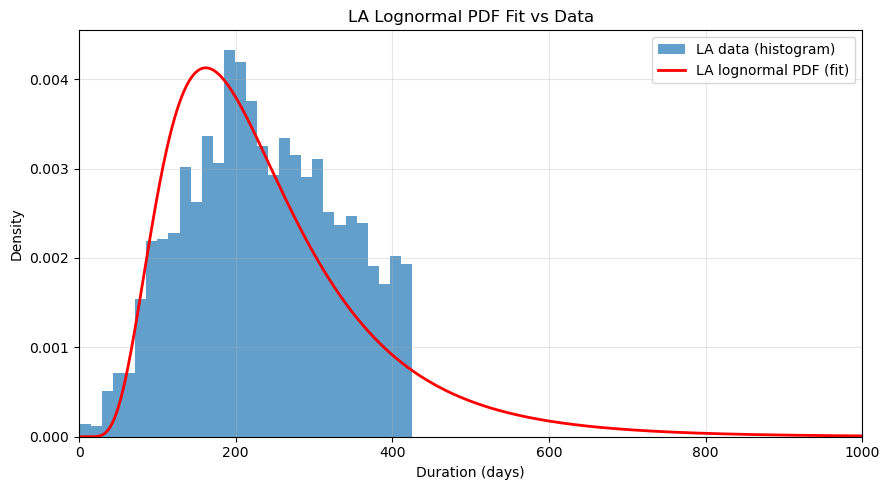

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Load LA data
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values

# Fit a lognormal to LA data (if you already have shape_la, loc_la, scale_la, skip this line)
shape_la, loc_la, scale_la = lognorm.fit(data_la, floc=0)

# x-grid for the PDF (force 0–1000 days)
x = np.linspace(0, 1000, 1000)

# LA lognormal PDF
pdf_la = lognorm.pdf(x, shape_la, loc=loc_la, scale=scale_la)

plt.figure(figsize=(9, 5))

# Histogram of LA data, but only show 0–1000 on x-axis
plt.hist(data_la, bins=30, density=True, alpha=0.7, label="LA data (histogram)")

plt.plot(x, pdf_la, 'r-', linewidth=2, label="LA lognormal PDF (fit)")

plt.xlabel("Duration (days)")
plt.ylabel("Density")
plt.title("LA Lognormal PDF Fit vs Data")
plt.xlim(0, 1000)        # <- key line
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
import numpy as np
import pandas as pd
from scipy.stats import lognorm, kstest, anderson

# Load Marshall Fire / Louisville data
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values

# Fit lognormal (Marshall) – if you already have shape, loc, scale you can skip refitting
shape_m, loc_m, scale_m = lognorm.fit(data_la, floc=0)

# 1) Kolmogorov–Smirnov test for fitted lognormal
#    H0: data come from Lognormal(shape_m, loc_m, scale_m)
ks_stat, ks_p = kstest(
    data_la,
    'lognorm',
    args=(shape_m, loc_m, scale_m)
)

# 2) Anderson–Darling test for lognormal
ad_result = anderson(np.log(data_la), dist='norm')  # log of data should be normal
ad_stat = ad_result.statistic
ad_crit = ad_result.critical_values
ad_sig = ad_result.significance_level

# 3) Log-likelihood, AIC, BIC for the fitted lognormal
n = len(data_marshal)
logpdf_vals = lognorm.logpdf(data_marshal, shape_m, loc=loc_m, scale=scale_m)
loglik = np.sum(logpdf_vals)

k = 3  # number of parameters: shape, loc, scale (loc fixed at 0 => k=2 if you used floc=0)
aic = 2 * k - 2 * loglik
bic = k * np.log(n) - 2 * loglik

print("Marshall lognormal fit parameters:")
print(f"  shape = {shape_m:.6f}, loc = {loc_m:.6f}, scale = {scale_m:.6f}\n")

print("Kolmogorov–Smirnov test:")
print(f"  KS statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}\n")

print("Anderson–Darling test on log-data vs Normal (lognormal check):")
print(f"  AD statistic = {ad_stat:.4f}")
for sl, cv in zip(ad_sig, ad_crit):
    print(f"  Critical value {cv:.4f} at significance level {sl:.1f}%")
print()

print("Information criteria for lognormal fit:")
print(f"  Log-likelihood = {loglik:.2f}")
print(f"  AIC = {aic:.2f}")
print(f"  BIC = {bic:.2f}")

Marshall lognormal fit parameters:
  shape = 0.521911, loc = 0.000000, scale = 212.239252

Kolmogorov–Smirnov test:
  KS statistic = 0.0917, p-value = 0.0000

Anderson–Darling test on log-data vs Normal (lognormal check):
  AD statistic = 52.1888
  Critical value 0.5750 at significance level 15.0%
  Critical value 0.6550 at significance level 10.0%
  Critical value 0.7860 at significance level 5.0%
  Critical value 0.9170 at significance level 2.5%
  Critical value 1.0910 at significance level 1.0%

Information criteria for lognormal fit:
  Log-likelihood = -3840.59
  AIC = 7687.18
  BIC = 7699.79


In [18]:
import numpy as np
import pandas as pd
from scipy.stats import lognorm
from scipy.optimize import minimize

# --- Data and censoring setup ---
N_total = 6410
censor_time = 425  # days

df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values

# Treat all observed applications as exact (<= 425 days)
observed = data_la  # if there are any >425, you can clip or handle separately
n_obs = len(observed)

# --- Negative log-likelihood for right-censored lognormal with loc=0 ---
# Parameterization: sigma > 0, mu is log-mean; scipy: shape = sigma, scale = exp(mu)
def neg_loglik(params):
    sigma, mu = params
    if sigma <= 0:
        return np.inf
    scale = np.exp(mu)

    # log f(t_i)
    logpdf = lognorm.logpdf(observed, s=sigma, loc=0, scale=scale)
    # log S(censor_time)
    S_c = 1.0 - lognorm.cdf(censor_time, s=sigma, loc=0, scale=scale)
    if S_c <= 0:
        return np.inf
    loglik = np.sum(logpdf) + (N_total - n_obs) * np.log(S_c)
    return -loglik

# --- Initial values from naive (uncensored) fit ---
sigma0, loc0, scale0 = lognorm.fit(observed, floc=0)
mu0 = np.log(scale0)

res = minimize(
    neg_loglik,
    x0=np.array([sigma0, mu0]),
    method="L-BFGS-B",
    bounds=[(1e-6, None), (None, None)],
)

sigma_c, mu_c = res.x
scale_c = np.exp(mu_c)

print("Censored lognormal fit for LA (loc = 0):")
print(f"  sigma (shape) = {sigma_c:.6f}")
print(f"  mu (log-mean) = {mu_c:.6f}")
print(f"  scale = exp(mu) = {scale_c:.6f}")
print(f"  success = {res.success}, message = {res.message}")

Censored lognormal fit for LA (loc = 0):
  sigma (shape) = 0.885952
  mu (log-mean) = 6.095819
  scale = exp(mu) = 443.997479
  success = True, message = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


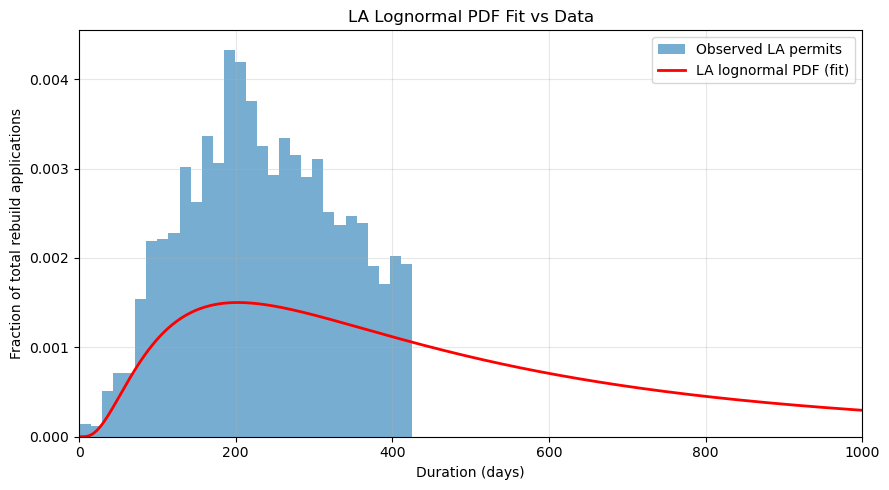

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Load LA data
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values

# x-grid for the PDF (force 0–1000 days)
x = np.linspace(0, 1000, 1000)

# LA lognormal PDF
pdf_la = lognorm.pdf(x, sigma_c, loc=0, scale=scale_c)

plt.figure(figsize=(9, 5))

# Histogram of LA data, but only show 0–1000 on x-axis
target_fraction = 3072 / 6410
weights = np.ones_like(data_la) * (target_fraction / len(data_la))

plt.hist(data_la,
         bins=30,
         density=True,
         weights=weights,
         alpha=0.6,
         label="Observed LA permits")

plt.plot(x, pdf_la, 'r-', linewidth=2, label="LA lognormal PDF (fit)")

plt.xlabel("Duration (days)")
plt.ylabel("Fraction of total rebuild applications")
plt.title("LA Lognormal PDF Fit vs Data")
plt.xlim(0, 1000)        # <- key line
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

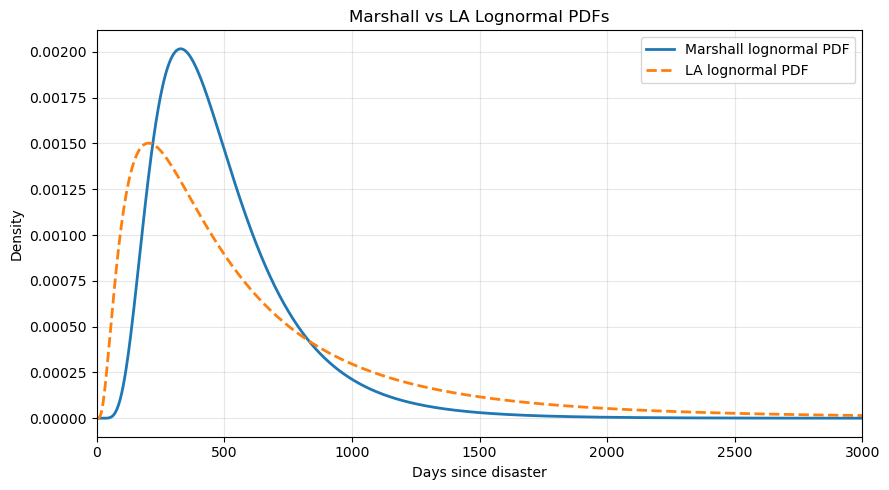

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Assumes you already have:
# Marshall: shape, loc, scale
# LA:       shape_la, loc_la, scale_la

# Common x-range for PDFs
x_pdf = np.linspace(0, 3000, 1000)

# Marshall lognormal PDF
pdf_marshall = lognorm.pdf(x_pdf, shape, loc=loc, scale=scale)

# LA lognormal PDF
pdf_la = lognorm.pdf(x_pdf, sigma_c, loc=loc_la, scale=scale_c)

plt.figure(figsize=(9, 5))

plt.plot(x_pdf, pdf_marshall, label="Marshall lognormal PDF", linewidth=2)
plt.plot(x_pdf, pdf_la, label="LA lognormal PDF", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Density")
plt.title("Marshall vs LA Lognormal PDFs")
plt.xlim(0, 3000)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

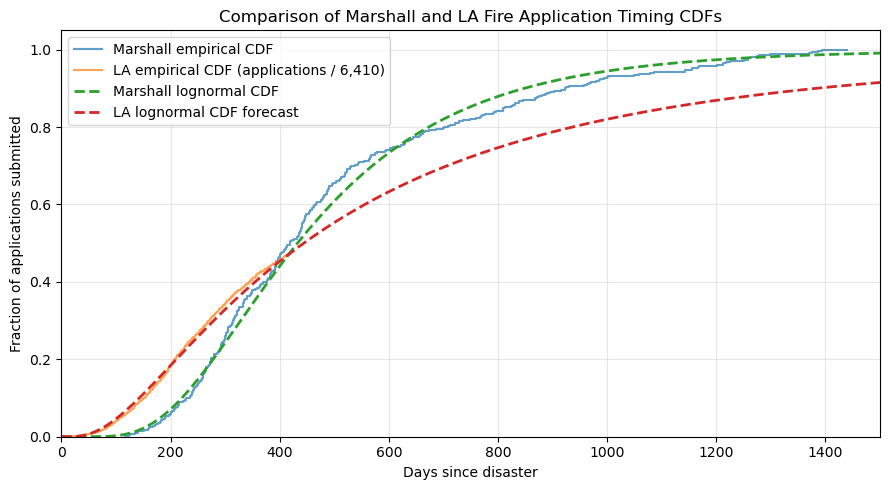

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

N_la = 6410  # total expected LA applications

# --- Load LA data ---
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values
data_la_sorted = np.sort(data_la)
n_la = len(data_la_sorted)

# LA empirical CDF as fraction of total expected LA applications
empirical_cdf_la = np.arange(1, n_la + 1) / N_la

# --- Load Marshall data (empirical) ---
df_marshall = pd.read_csv("disaster_to_application_louisville.csv")
data_marshall = df_marshall["duration_days"].values
data_marshall_sorted = np.sort(data_marshall)
n_marshall = len(data_marshall_sorted)

# Marshall empirical CDF (assume dataset includes all Marshall applications)
empirical_cdf_marshall = np.arange(1, n_marshall + 1) / n_marshall

# --- Horizon for model CDFs ---
x_forecast = np.linspace(0, 3000, 1000)

# Marshall lognormal CDF (Marshall fit: shape, loc, scale)
cdf_marshall = lognorm.cdf(x_forecast, shape, loc, scale)

# LA lognormal CDF forecast (LA fit: shape_la, loc_la, scale_la)
cdf_la_forecast = lognorm.cdf(x_forecast, sigma_c, loc_la, scale_c)

plt.figure(figsize=(9, 5))

# Marshall empirical CDF (raw Marshall data)
plt.step(
    data_marshall_sorted, empirical_cdf_marshall, where="post",
    label="Marshall empirical CDF", alpha=0.7
)

# LA empirical CDF (raw LA data, scaled by 6,410)
plt.step(
    data_la_sorted, empirical_cdf_la, where="post",
    label="LA empirical CDF (applications / 6,410)", alpha=0.7
)

# Marshall lognormal CDF
plt.plot(
    x_forecast, cdf_marshall,
    label="Marshall lognormal CDF", linestyle="--", linewidth=2
)

# LA lognormal CDF forecast
plt.plot(
    x_forecast, cdf_la_forecast,
    label="LA lognormal CDF forecast", linestyle="--", linewidth=2
)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Comparison of Marshall and LA Fire Application Timing CDFs")
plt.xlim(0, 1500)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()